In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc)

sns.set_theme(style="whitegrid")
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

In [42]:

df = pd.read_csv("spam.csv")

df = df.drop_duplicates()

X = df.drop('class', axis=1)
y = df['class']

print(f"Dataset Shape: {df.shape}")
print(f"Class Distribution:\n{y.value_counts(normalize=True)}")

Dataset Shape: (4210, 58)
Class Distribution:
class
0    0.601188
1    0.398812
Name: proportion, dtype: float64


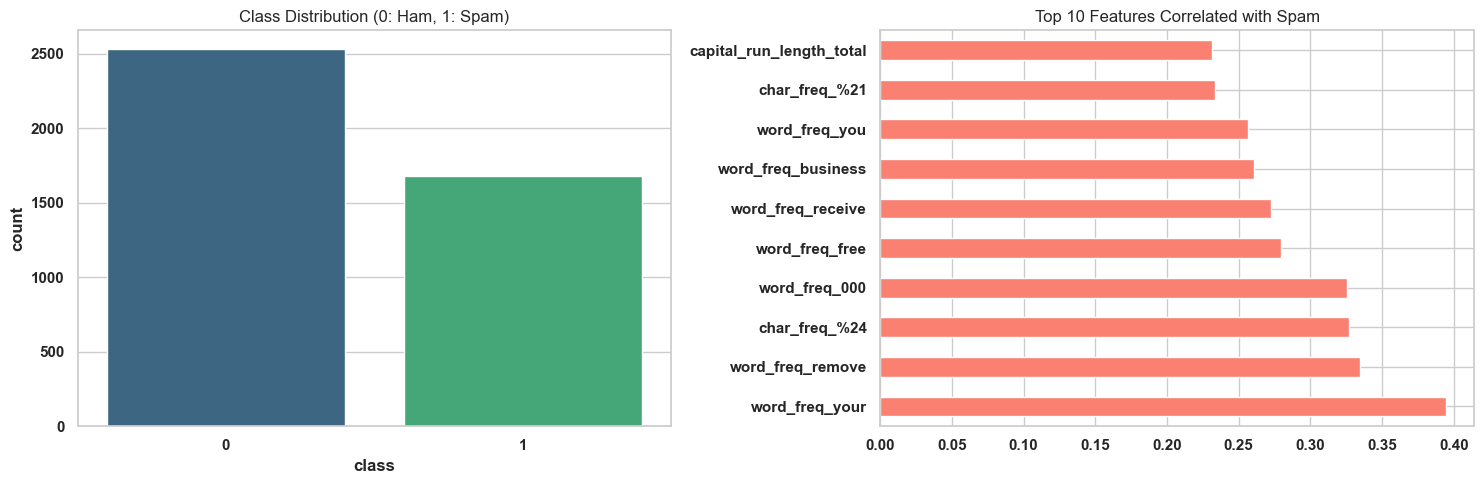

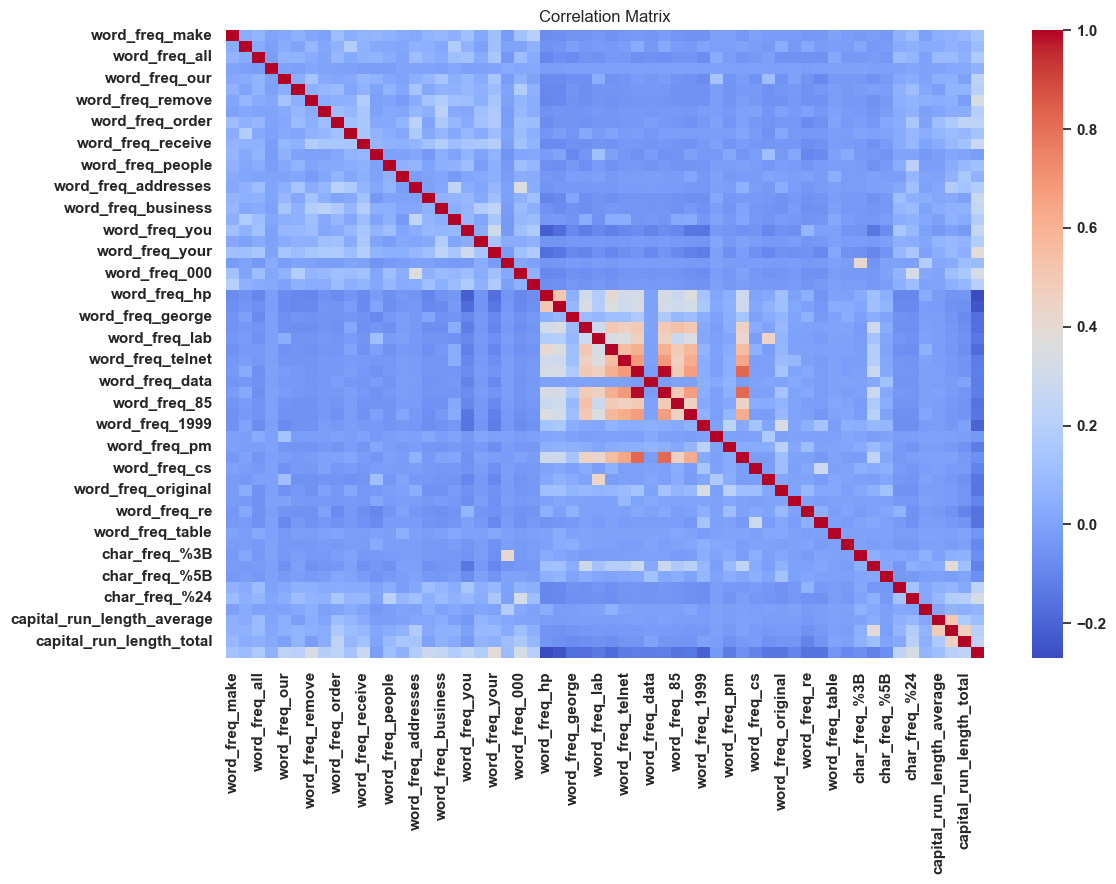

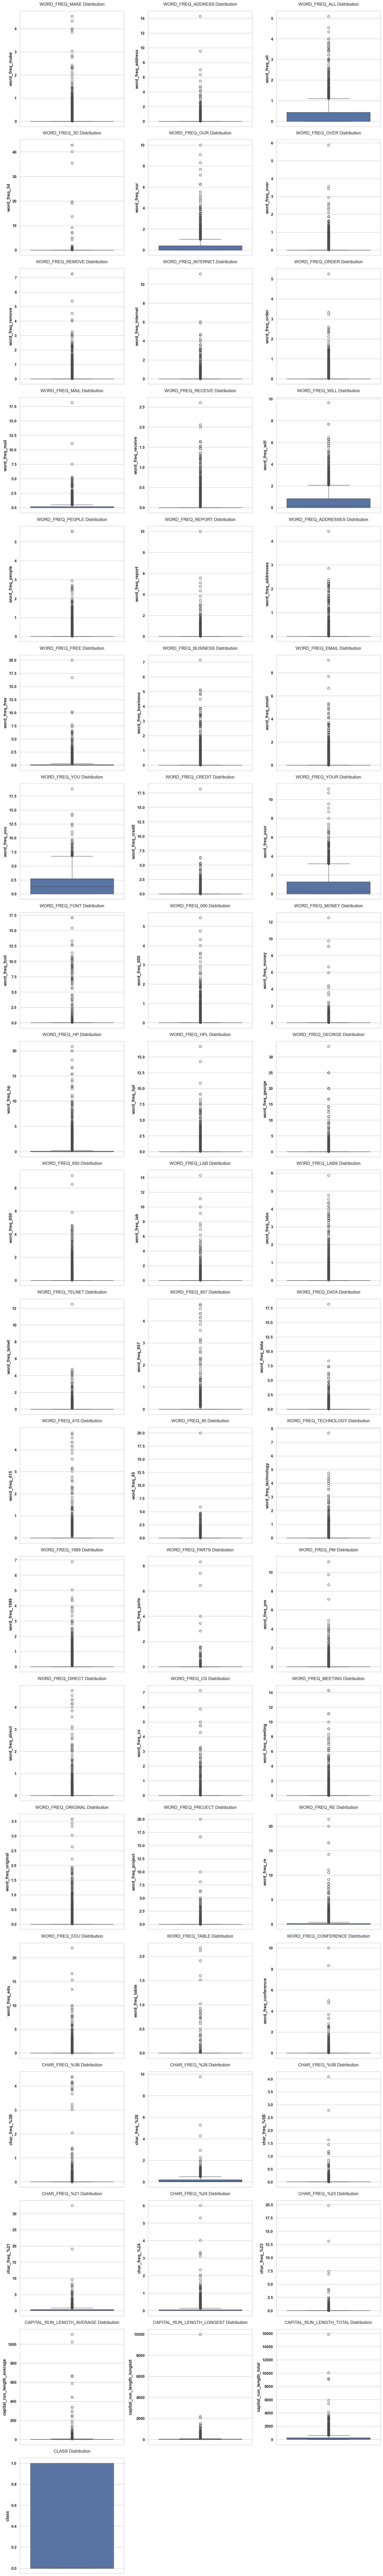

In [43]:
import math


def perform_experiment_eda(df, target):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    sns.countplot(x=target, data=df, palette='viridis',hue=target,legend=False)
    plt.title("Class Distribution (0: Ham, 1: Spam)")

    plt.subplot(1, 2, 2)
    correlations = df.corr()[target].sort_values(ascending=False).head(11).drop(target)
    correlations.plot(kind='barh', color='salmon')
    plt.title("Top 10 Features Correlated with Spam")

    plt.tight_layout()
    plt.show()
    cols = df.columns
    plt.figure(figsize=(12,9))
    sns.heatmap(df[cols].corr(), cmap="coolwarm")
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()
    ncols = 3
    nrows = math.ceil(len(cols) / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
    axes = axes.flatten()

    bxwidth = 1
    for i, col in enumerate(cols):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(f"{col.upper()} Distribution", pad=15)
        axes[i].set_ylabel(col)
        for spine in axes[i].spines.values():
            spine.set_linewidth(bxwidth)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.subplots_adjust(hspace=1.2, wspace=0.8)
    plt.tight_layout()
    plt.show()

perform_experiment_eda(df, 'class')

In [44]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

In [45]:
def evaluate_model_comprehensive(model, X_test_data, y_test_data, name):
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1]

    acc = accuracy_score(y_test_data, y_pred)
    prec = precision_score(y_test_data, y_pred)
    rec = recall_score(y_test_data, y_pred)
    f1 = f1_score(y_test_data, y_pred)

    cm = confusion_matrix(y_test_data, y_pred)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    fpr, tpr, thresholds = roc_curve(y_test_data, y_prob)
    roc_auc = auc(fpr, tpr)

    return {
        "Name": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1": f1, "Specificity": spec,
        "AUC": roc_auc, "CM": cm, "FPR": fpr, "TPR": tpr
    }

In [54]:
import time
nb_results = []
nb_variants = [
    ("Gaussian NB", GaussianNB(), X_train_std, X_test_std),
    ("Multinomial NB", MultinomialNB(), X_train_mm, X_test_mm),
    ("Bernoulli NB", BernoulliNB(), X_train_std, X_test_std)
]

for name, model, xt, xv in nb_variants:
    ts = time.time()
    model.fit(xt, y_train)
    nb_results.append(evaluate_model_comprehensive(model, xv, y_test, name))
    te = time.time()
    print(f"{name}  Time: {te - ts:.4f} seconds")
knn_results = []

for algo in ['kd_tree', 'ball_tree']:
    knn = KNeighborsClassifier(n_neighbors=7, algorithm=algo)
    ts= time.time()
    knn.fit(X_train_std, y_train)
    knn_results.append(evaluate_model_comprehensive(knn, X_test_std, y_test, f"KNN ({algo})"))
    te = time.time()
    print(f"KNN ({algo})  Time: {te - ts:.4f}) seconds")

all_results = nb_results + knn_results

Gaussian NB  Time: 0.0097 seconds
Multinomial NB  Time: 0.0062 seconds
Bernoulli NB  Time: 0.0078 seconds
KNN (kd_tree)  Time: 0.2393) seconds
KNN (ball_tree)  Time: 0.2343) seconds


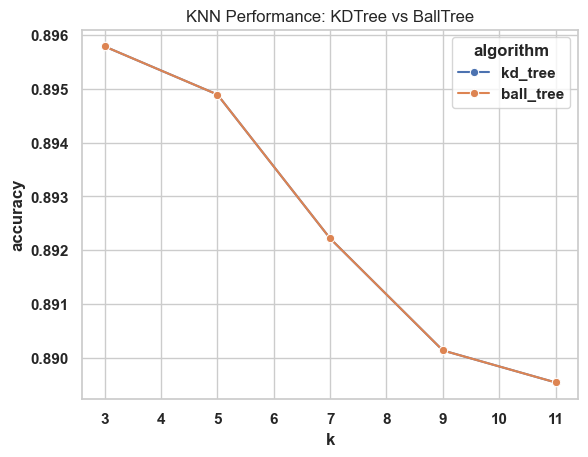

In [47]:
k_values = [3, 5, 7, 9, 11]
knn_results = []

for k in k_values:
    for algo in ['kd_tree', 'ball_tree']:
        knn = KNeighborsClassifier(n_neighbors=k, algorithm=algo)
        scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
        knn_results.append({'k': k, 'algorithm': algo, 'accuracy': scores.mean()})

df_knn = pd.DataFrame(knn_results)
sns.lineplot(data=df_knn, x='k', y='accuracy', hue='algorithm', marker='o')
plt.title("KNN Performance: KDTree vs BallTree")
plt.show()

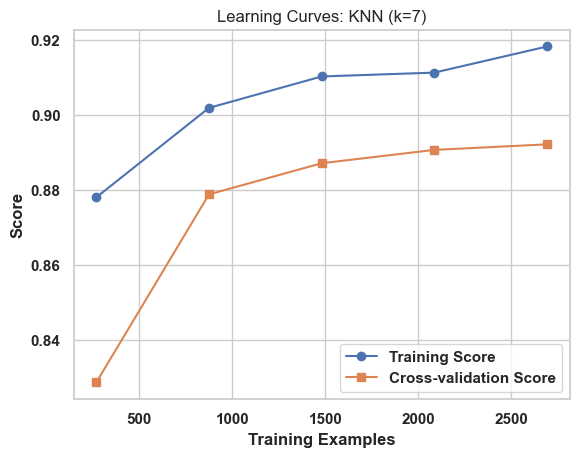

In [48]:
def plot_learning_curves(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5))

    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Training Score")
    plt.plot(train_sizes, np.mean(test_scores, axis=1), 's-', label="Cross-validation Score")
    plt.title(f"Learning Curves: {title}")
    plt.xlabel("Training Examples"), plt.ylabel("Score"), plt.legend()
    plt.show()

plot_learning_curves(KNeighborsClassifier(n_neighbors=7), X_train_scaled, y_train, "KNN (k=7)")

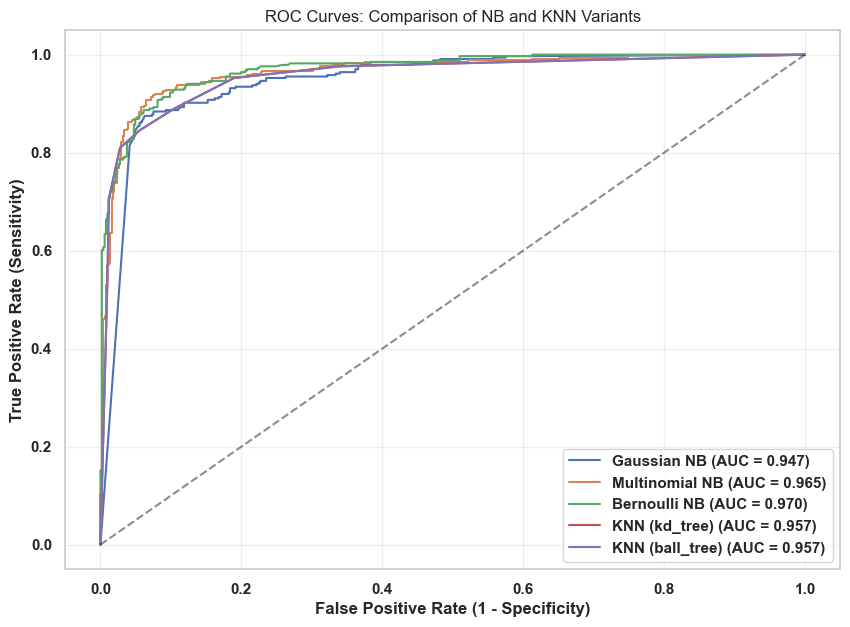

In [49]:
plt.figure(figsize=(10, 7))

for res in all_results:
    plt.plot(res["FPR"], res["TPR"], label=f'{res["Name"]} (AUC = {res["AUC"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves: Comparison of NB and KNN Variants')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

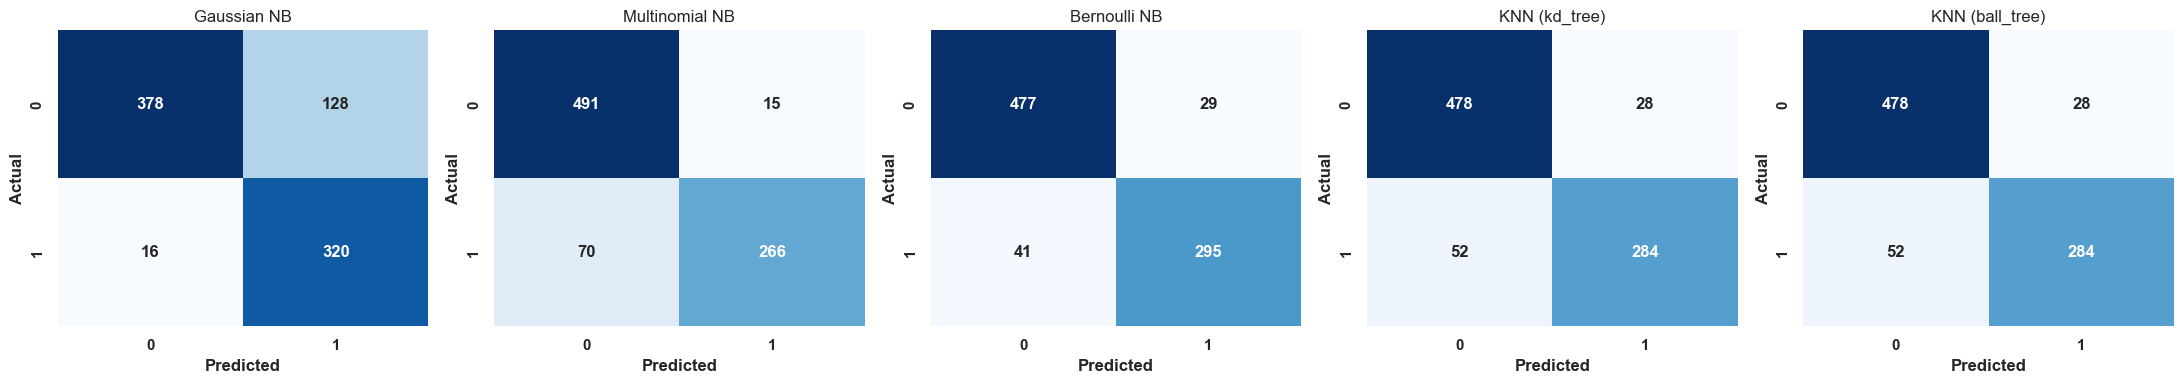

In [50]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, res in enumerate(all_results):
    sns.heatmap(res["CM"], annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(res["Name"])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [51]:

final_summary = pd.DataFrame({
    "Model Type": ["Naive Bayes", "Naive Bayes", "Naive Bayes", "KNN", "KNN"],
    "Variant/Algorithm": ["Gaussian", "Multinomial", "Bernoulli", "KDTree (k=7)", "BallTree (k=7)"],
    "Best Accuracy": [results_nb["Gaussian NB"], results_nb["Multinomial NB"],
                       results_nb["Bernoulli NB"], df_knn.loc[5, 'accuracy'], df_knn.loc[4, 'accuracy']],
    "Observation": ["Handles continuous features", "Best for frequency data", "Best for binary data",
                    "High accuracy, slow search", "Fastest search performance"]
})

display(final_summary)

,Model Type,Variant/Algorithm,Best Accuracy,Observation
0,Naive Bayes,Gaussian,0.828979,Handles continuous features
1,Naive Bayes,Multinomial,0.899050,Best for frequency data
2,Naive Bayes,Bernoulli,0.916865,Best for binary data
3,KNN,KDTree (k=7),0.892220,"High accuracy, slow search"
4,KNN,BallTree (k=7),0.892220,Fastest search performance
